# Targeted Carlini-Wagner (CW) Attack

This notebook demonstrates the targeted Carlini-Wagner attack on Whisper.

**Goal:** Modify an audio sample so Whisper outputs a *specific target phrase* instead of the original content.

**Method:**
1.  Initialize perturbation (random noise).
2.  Optimize perturbation to minimize $L_2$ distance from original audio.
3.  Optimize perturbation to *maximize* the log-probability of the target tokens.
4.  Apply constraints.

In [1]:
import os
import torch
import librosa
import soundfile as sf
import numpy as np
from jiwer import wer, cer
from tqdm import tqdm
import json
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt 
import jiwer


from IPython.display import Audio, display

import warnings
import sys

from src.models.whisper_wrapper import WhisperASRWithAttack
import src.attacks as attacks
import src.data as data_loader

import whisper

torch.manual_seed(42)
np.random.seed(42)

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


In [2]:

model_name = "small"

audio_ds = data_loader.load_dataset()
model = WhisperASRWithAttack(device=device)
print(f"Loaded {len(audio_ds)} samples")

Found 2620 audio files.
Sample: /Users/victorhugogermano/Development/soundfinal/data/LibriSpeech/test-clean/61/70970/61-70970-0040.flac


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Loaded 2620 samples


In [3]:
def get_ground_truth(audio_path: Path):
    # LibriSpeech structure: test-clean/speaker/chapter/file.flac
    # Trans file: test-clean/speaker/chapter/speaker-chapter.trans.txt
    chapter_dir = audio_path.parent
    speaker_id = audio_path.parts[-3]
    chapter_id = audio_path.parts[-2]
    trans_file = chapter_dir / f"{speaker_id}-{chapter_id}.trans.txt"
    
    if not trans_file.exists():
        return None
        
    with open(trans_file, 'r') as f:
        for line in f:
            parts = line.split()
            if parts[0] == audio_path.stem:
                return " ".join(parts[1:]).strip().lower()
    return None

In [4]:
audio_path = audio_ds[0]
ground_truth = get_ground_truth(Path(audio_path))
print(f"Ground Truth Transcription: {ground_truth}")
clean_audio, audio_tensor = data_loader.load_audio_tensor(audio_path)
print(f"Sample Rate: {data_loader.TARGET_SAMPLE_RATE} Hz, Audio Shape: {clean_audio.shape}")
display(Audio(audio_tensor, rate=data_loader.TARGET_SAMPLE_RATE))

Ground Truth Transcription: they regained their apartment apparently without disturbing the household of gamewell
Sample Rate: 16000 Hz, Audio Shape: (66640,)


In [5]:
# Define the target phrase Whisper should output after the attack
target_phrase = "hello world"
print(f"Target phrase : {target_phrase}")

# Instantiate CW attack
cw_attack = attacks.CWAuditoryAttack(
    whisper_model=model,
    device=device,
    learning_rate=0.01,
    c=1.0,
    steps=100,
)

# Run attack — returns 1-D adversarial tensor on CPU
adv_audio = cw_attack.attack(audio_tensor, target_phrase)



Target phrase : hello world


CW Attack:   0%|          | 0/100 [00:00<?, ?it/s]/opt/homebrew/anaconda3/envs/capstone/lib/python3.11/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 3001, 201]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]
CW Attack:   2%|▏         | 2/100 [00:00<00:28,  3.46it/s]

  step    0/100 | loss=16.1178 (l2=0.0000, ce=16.1178)


CW Attack:   5%|▌         | 5/100 [00:01<00:20,  4.63it/s]

  step    3/100 | loss=20.6028 (l2=5.9114, ce=14.6914)


...

CW Attack:  95%|█████████▌| 95/100 [00:19<00:00,  5.08it/s]

  step   93/100 | loss=14.3280 (l2=6.7567, ce=7.5713)


CW Attack:  98%|█████████▊| 98/100 [00:19<00:00,  5.07it/s]

  step   96/100 | loss=13.4949 (l2=6.5600, ce=6.9349)


  step   99/100 | loss=12.7154 (l2=5.7687, ce=6.9467)


In [6]:

# Save both versions for playback / evaluation
#sf.write("targeted_attack_clean.wav", clean_audio, samplerate=16000)
#sf.write("targeted_attack_adv.wav",   adv_audio.numpy(),   samplerate=16000)

snr = attacks.compute_snr(clean_audio, adv_audio.numpy())
print(f"\nSNR (clean vs adversarial): {snr:.2f} dB")


SNR (clean vs adversarial): 18.93 dB


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.


  EVALUATION
Ground truth    : they regained their apartment apparently without disturbing the household of gamewell
Target phrase   : hello world

Clean prediction: They regain their apartment, apparently, without disturbing the household of Gainwell.
Adv. prediction : He Lee Ye Loyal Cartament, apparently without disturbing the household of Gainwell.

WER  (clean)    : 0.364
WER  (adv)      : 0.545
SNR             : 18.93 dB
Attack success  : NO  ✗


/opt/homebrew/anaconda3/envs/capstone/lib/python3.11/site-packages/matplotlib/axes/_axes.py:8283: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


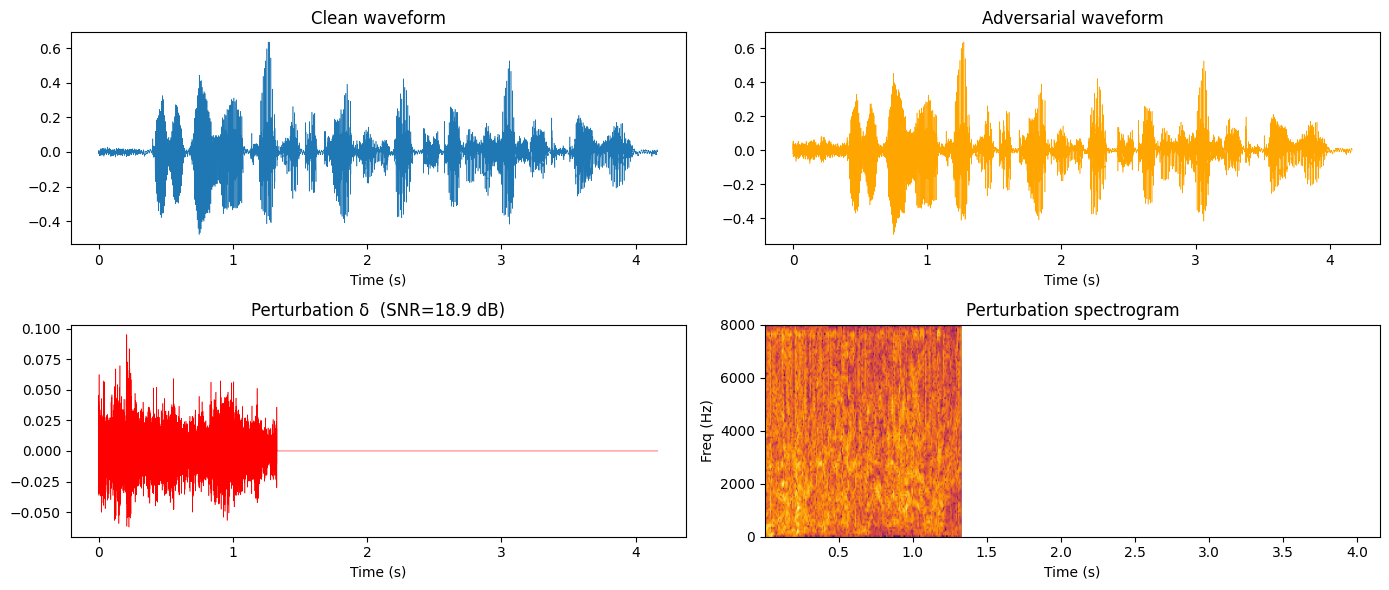


--- Playback ---
Clean:


Adversarial:


In [7]:
# Evaluate Results


print("=" * 55)
print("  EVALUATION")
print("=" * 55)

pred_clean = model.transcribe(audio_tensor)
pred_adv   = model.transcribe(adv_audio)

wer_clean = jiwer.wer(ground_truth, pred_clean.lower())
wer_adv   = jiwer.wer(ground_truth, pred_adv.lower())

attack_success = target_phrase.lower() in pred_adv.lower()

print(f"Ground truth    : {ground_truth}")
print(f"Target phrase   : {target_phrase}")
print()
print(f"Clean prediction: {pred_clean}")
print(f"Adv. prediction : {pred_adv}")
print()
print(f"WER  (clean)    : {wer_clean:.3f}")
print(f"WER  (adv)      : {wer_adv:.3f}")
print(f"SNR             : {snr:.2f} dB")
print(f"Attack success  : {'YES ✓' if attack_success else 'NO  ✗'}")
print("=" * 55)

# --- Waveform & spectrogram comparison ---
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
t = np.linspace(0, len(audio_tensor) / 16000, len(audio_tensor))

axes[0, 0].plot(t, audio_tensor.numpy(), linewidth=0.4)
axes[0, 0].set_title("Clean waveform")
axes[0, 0].set_xlabel("Time (s)")

axes[0, 1].plot(t[:len(adv_audio)], adv_audio.numpy(), linewidth=0.4, color="orange")
axes[0, 1].set_title("Adversarial waveform")
axes[0, 1].set_xlabel("Time (s)")

delta_np = (adv_audio - audio_tensor[:len(adv_audio)]).numpy()
axes[1, 0].plot(t[:len(delta_np)], delta_np, linewidth=0.4, color="red")
axes[1, 0].set_title(f"Perturbation δ  (SNR={snr:.1f} dB)")
axes[1, 0].set_xlabel("Time (s)")

axes[1, 1].specgram(delta_np, Fs=16000, cmap="inferno")
axes[1, 1].set_title("Perturbation spectrogram")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("Freq (Hz)")

plt.tight_layout()
plt.show()

print("\n--- Playback ---")
print("Clean:")
display(Audio(audio_tensor.numpy(), rate=16000))
print("Adversarial:")
display(Audio(adv_audio.numpy(), rate=16000))


### Observations
- Targeted attacks are significantly harder than untargeted attacks (which just try to break the model).
- The perturbation might be larger to successfully override the original semantic information.
- If `result_adv['text']` contains the target phrase, the attack is successful.

In [8]:
import random

from matplotlib.pyplot import step
# Batch evaluation — 5 utterances, single target phrase
N_SAMPLES  = 5
TARGET     = "hello world"
STEPS      = 100

batch_cw = attacks.CWAuditoryAttack(

    whisper_model=model,
    device=device,
    learning_rate=0.01,
    c=1.0,
    steps=STEPS,
)

random.seed(42)
sample_files = random.sample(list(audio_ds), min(N_SAMPLES, len(audio_ds)))
rows = []
step = 0
for fp in sample_files:
    fp = Path(fp)
    _, audio = data_loader.load_audio_tensor(str(fp))

    # Ground truth
    tf = fp.parent / f"{fp.parent.parent.name}-{fp.parent.name}.trans.txt"
    gt = ""
    if tf.exists():
        with open(tf) as f:
            for line in f:
                uid, *words = line.strip().split()
                if uid == fp.stem:
                    gt = " ".join(words).lower()
                    break

    adv = batch_cw.attack(audio, TARGET)

    pred_c = model.transcribe(audio).lower()
    pred_a = model.transcribe(adv).lower()
    snr_i  = attacks.compute_snr(audio.numpy(), adv.numpy())
    succ   = TARGET in pred_a

    rows.append({
        "file"        : fp.name,
        "ground_truth": gt,
        "clean_pred"  : pred_c,
        "adv_pred"    : pred_a,
        "WER_clean"   : round(jiwer.wer(gt, pred_c), 3),
        "WER_adv"     : round(jiwer.wer(gt, pred_a), 3),
        "SNR_dB"      : round(snr_i, 2),
        "success"     : succ,
    })
    #if step % max(1, step // 60) == 0:
        #print(f"[{'✓' if succ else '✗'}] {fp.name}  SNR={snr_i:.1f}dB  adv='{pred_a}'")
    #step += 1

results_df = pd.DataFrame(rows)
print("\n--- Batch Summary ---")
print(results_df[["file", "WER_clean", "WER_adv", "SNR_dB", "success"]].to_string(index=False))
print(f"\nAttack success rate : {results_df['success'].mean():.0%}")
print(f"Mean SNR            : {results_df['SNR_dB'].mean():.2f} dB")
print(f"Mean WER (clean)    : {results_df['WER_clean'].mean():.3f}")
print(f"Mean WER (adv)      : {results_df['WER_adv'].mean():.3f}")


CW Attack:   2%|▏         | 2/100 [00:00<00:20,  4.83it/s]

  step    0/100 | loss=15.0704 (l2=0.0000, ce=15.0704)


CW Attack:   5%|▌         | 5/100 [00:01<00:19,  4.97it/s]

  step    3/100 | loss=18.4128 (l2=5.7470, ce=12.6658)


CW Attack:   7%|▋         | 7/100 [00:01<00:18,  4.99it/s]

...

CW Attack:  94%|█████████▍| 94/100 [00:18<00:01,  4.91it/s]

  step   93/100 | loss=13.7696 (l2=7.7661, ce=6.0035)


CW Attack:  98%|█████████▊| 98/100 [00:19<00:00,  5.01it/s]

  step   96/100 | loss=14.7728 (l2=9.5230, ce=5.2498)


  step   99/100 | loss=15.8884 (l2=11.5702, ce=4.3182)

--- Batch Summary ---
                 file  WER_clean  WER_adv    SNR_dB  success
  3570-5695-0014.flac      0.091    1.000 23.350000    False
8463-294825-0002.flac      0.318    0.955 19.790001    False
   61-70968-0004.flac      0.182    0.727 13.190000    False
  1284-1181-0013.flac      0.095    0.238 20.900000    False
 5683-32865-0000.flac      0.250    1.750  9.310000    False

Attack success rate : 0%
Mean SNR            : 17.31 dB
Mean WER (clean)    : 0.187
Mean WER (adv)      : 0.934
